# Assignment 06 — ST: S&P 500 daily returns with RNNs

**Dataset:** S&P 500 daily prices, 2013-02-08 → 2018-02-07 (Kaggle `camnugent/sandp500`). **Task:** for each of the 350 most liquid stocks, read the last **30 trading days** (4 features) and predict the **log return of the next day** (many-to-one regression, one pooled model for all tickers).
**Runs:** `ST-SC-RNN` (NumPy), `ST-TF-RNN` (Keras), `ST-PT-RNN` (PyTorch) with identical architecture and starting weights, plus LSTM/GRU in Keras and PyTorch.
**Honest expectation:** daily returns are close to a random walk, so a test R² near 0 and a directional accuracy of 50–53 % are the *correct* outcome. The purpose is a fair comparison of implementations, not a trading strategy.
Concepts and formulas are in [00_rnn_concepts.ipynb](00_rnn_concepts.ipynb).

## 1. Setup

One seed (42) for Python, NumPy, Keras and PyTorch; one set of hyper-parameters for every implementation (hidden size 32, Adam lr 1e-3, batch 128, at most 30 epochs, early stopping with patience 5 on validation loss, gradient clipping at global norm 1.0). Run IDs follow `<dataset>-<implementation>-<model>`: `SC` = NumPy scratch, `TF` = Keras, `PT` = PyTorch. Setting `A6_SMOKE=1` shrinks everything for a quick test and writes to `smoke/` folders.

In [1]:
import os, time, json, random, warnings
from pathlib import Path
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.nn.functional as Fn
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})

SEED = 42
SMOKE = os.environ.get("A6_SMOKE") == "1"          # quick test: few series, 2 epochs, outputs go to */smoke/
random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED); torch.manual_seed(SEED)

CODE = "ST"
DATA = Path("../dataset/st")
RES = Path("results") / ("smoke" if SMOKE else "")
IMG = Path("../report/images") / ("smoke" if SMOKE else "")
RES.mkdir(parents=True, exist_ok=True); IMG.mkdir(parents=True, exist_ok=True)

# one fixed set of hyper-parameters for every implementation (PLAN 3.4)
H, BATCH, LR, EPS, CLIP, PATIENCE = 32, 128, 1e-3, 1e-7, 1.0, 5
MAX_EPOCHS = 2 if SMOKE else 30
T = 30                                              # window length

dev = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| PyTorch", torch.__version__)
print("TF GPUs:", tf.config.list_physical_devices("GPU"), "| PT device:", dev, "| smoke:", SMOKE)

TensorFlow 2.21.0 | Keras 3.15.1 | PyTorch 2.14.0+cpu


TF GPUs: [] | PT device: cpu | smoke: False


## 2. Data

Steps: keep the 470 tickers with the full 1,259-day history → rank by mean dollar volume (close × volume) and keep the top 350 (all share the same dates) → build 4 features per day → z-score on the **train period only**.

| Feature | Meaning | Transform |
|---|---|---|
| `ret` (**target**) | $\ln(\mathrm{close}_t/\mathrm{close}_{t-1})$. A +1 % day is $\ln 1.01=0.00995$, −1 % is $-0.01005$ (symmetric, additive over days) | z-score |
| `hl_range` | $(\mathrm{high}-\mathrm{low})/\mathrm{close}$, intraday volatility | z-score |
| `oc_ret` | $\ln(\mathrm{close}/\mathrm{open})$, intraday direction | z-score |
| `vol_z` | $\ln(1+\mathrm{volume})$ | z-score **per ticker**, because share volumes differ by orders of magnitude |

Missing `open/high/low` values (a handful of rows) are replaced by that day's `close`.

**Split.** Chronological by *target date*, identical dates for every ticker: first 70 % of the 1,258 return days train, next 15 % validation, last 15 % test. Look-back may reach into the previous split; targets never do.

**Metrics.** RMSE and MAE in log-return units; out-of-sample R² vs the train-mean predictor; **directional accuracy** (sign of prediction = sign of return; compare with the always-up rate printed below); **information coefficient** (correlation of prediction and truth). Baselines: zero return, previous-day return, train mean.

In [2]:
N_SERIES = 30 if SMOKE else 350
raw = pd.read_csv(DATA / "all_stocks_5yr.csv", parse_dates=["date"])
cnt = raw.groupby("Name").size(); complete = cnt[cnt == cnt.max()].index              # tickers with the full 1,259-day history
raw = raw[raw.Name.isin(complete)]
top = (raw.close * raw.volume).groupby(raw.Name).mean().nlargest(N_SERIES).index        # most liquid = highest mean dollar volume
print(f"{len(raw):,} rows | {len(cnt)} tickers, {len(complete)} complete | using {len(top)} most liquid")
piv = lambda c: raw.pivot(index="date", columns="Name", values=c)[top]
close = piv("close"); opn = piv("open").fillna(close); high = piv("high").fillna(close); low = piv("low").fillna(close); vol = piv("volume")
assert close.notna().all().all() and vol.notna().all().all()
dates = close.index.to_numpy(); nS = len(top)
close_a = close.to_numpy().T                                                       # (n_series, days)
ret_raw = np.diff(np.log(close_a), axis=1)                                         # log returns, 1,258 days
D = ret_raw.shape[1]; days = dates[1:]
hl = ((high - low) / close).to_numpy().T[:, 1:]; oc = np.log(close / opn).to_numpy().T[:, 1:]; lv = np.log1p(vol.to_numpy().T)[:, 1:]

c1, c2 = int(0.70 * D), int(0.85 * D)                                              # chronological split on the target day (same dates for every ticker)
FEATS = ["ret", "hl_range", "oc_ret", "vol_z"]
S = np.stack([ret_raw, hl, oc, lv], -1).astype(np.float32)
mu = S[:, :c1, :3].reshape(-1, 3).mean(0); sd = S[:, :c1, :3].reshape(-1, 3).std(0)  # train period only
S[..., :3] = (S[..., :3] - mu) / sd
S[..., 3] = (S[..., 3] - S[:, :c1, 3].mean(1, keepdims=True)) / S[:, :c1, 3].std(1, keepdims=True)   # volume z-scored per ticker
mu_t, sd_t = float(mu[0]), float(sd[0])

def make_windows(lo, hi):
    ends = np.arange(max(lo - 1, T - 1), hi - 1)
    X = np.concatenate([S[:, t - T + 1:t + 1] for t in ends]); y = np.concatenate([S[:, t + 1, 0] for t in ends])
    return X, y, np.repeat(ends + 1, nS), np.tile(np.arange(nS), len(ends))
Xtr, ytr, tr_day, tr_ser = make_windows(0, c1)
Xva, yva, va_day, va_ser = make_windows(c1, c2)
Xte, yte, te_day, te_ser = make_windows(c2, D)
if not SMOKE: np.savez(DATA / "splits.npz", days=days, series=np.array(top), c1=c1, c2=c2, T=T, mu=mu, sd=sd)
print(f"windows: train {len(Xtr):,} | validation {len(Xva):,} | test {len(Xte):,} | total {len(Xtr)+len(Xva)+len(Xte):,}")
print(f"X shape (N, T, F) = {Xtr.shape} | split days: train < {str(days[c1])[:10]} <= validation < {str(days[c2])[:10]} <= test")

to_ret = lambda z: np.asarray(z) * sd_t + mu_t
KEY_METRIC = "rmse"
def metrics_fn(z_true, z_pred):
    """RMSE / MAE in log-return units; R2 against the train-mean predictor; directional accuracy; information coefficient."""
    rt, rp = to_ret(z_true), to_ret(z_pred)
    return dict(rmse=float(np.sqrt(np.mean((rt - rp) ** 2))), mae=float(np.mean(np.abs(rt - rp))),
                r2_oos=float(1 - np.sum((z_true - z_pred) ** 2) / np.sum(z_true ** 2)),
                dir_acc=float(np.mean(np.sign(rp) == np.sign(rt))) if np.std(rp) > 0 else float("nan"), ic=float(np.corrcoef(rt, rp)[0, 1]) if np.std(rp) > 0 else float("nan"))

z0 = float((0 - mu_t) / sd_t)
BASELINES = {"zero return": np.full(len(yte), z0, np.float32), "always up (+1e-6)": np.full(len(yte), (1e-6 - mu_t) / sd_t, np.float32), "previous-day return": Xte[:, -1, 0], "train mean": np.zeros(len(yte), np.float32)}
SHOW = int(np.where(np.array(top) == "AAPL")[0][0]) if "AAPL" in set(top) else 0
def overlay_slice(pred, n=120):
    ix = np.where(te_ser == SHOW)[0][-n:]
    return days[te_day[ix]], to_ret(yte[ix]), to_ret(pred[ix]), f"log return, {top[SHOW]}"
print("directional accuracy of always predicting 'up' on the test windows:", round(float(np.mean(to_ret(yte) > 0)), 4))

591,730 rows | 505 tickers, 470 complete | using 350 most liquid


windows: train 297,500 | validation 66,150 | test 66,150 | total 429,800
X shape (N, T, F) = (297500, 30, 4) | split days: train < 2016-08-09 <= validation < 2017-05-10 <= test
directional accuracy of always predicting 'up' on the test windows: 0.5306


### Shared evaluation helpers

Every run, whatever the implementation, goes through `finalize`: it predicts validation and test windows, computes the metrics above, stores a JSON record in `results/`, saves the loss and forecast figures and prints a one-line summary. Time per epoch is the median of epochs 2+ (epoch 1 includes one-time set-up).

In [3]:
RUNS = {}   # run_id -> result record (+ test predictions)

def median_epoch_time(times):
    times = list(times)
    return float(np.median(times[1:] if len(times) > 1 else times))   # epoch 1 includes one-time set-up

def infer_ms_per_1k(predict_fn, X, reps=3):
    n = min(len(X), 10000); ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); predict_fn(X[:n]); ts.append(time.perf_counter() - t0)
    return float(np.median(ts)) / n * 1e6

def plot_loss(run_id, hist):
    best = int(np.argmin(hist["val_loss"]))
    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    ax.plot(range(1, len(hist["loss"]) + 1), hist["loss"], label="train")
    ax.plot(range(1, len(hist["val_loss"]) + 1), hist["val_loss"], label="validation")
    ax.axvline(best + 1, ls=":", c="grey"); ax.set(xlabel="epoch", ylabel="MSE (z-scored target)", title=f"{run_id}: loss"); ax.legend()
    fig.savefig(IMG / f"{run_id}_loss.png"); plt.show()

def plot_forecast(run_id, pred):
    xs, actual, predicted, ylabel = overlay_slice(pred)
    fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [2.2, 1]})
    a.plot(xs, actual, label="actual", lw=1.5); a.plot(xs, predicted, label=run_id, lw=1.2)
    a.set(ylabel=ylabel, title=f"{run_id}: forecast on the test period (one series)"); a.legend(); a.tick_params(axis="x", rotation=30)
    res = yte - pred
    b.hist(res, bins=80, color="C2"); b.set(xlabel="residual (z-scored target)", title="residuals, all test windows")
    fig.savefig(IMG / f"{run_id}_forecast.png"); plt.show()

def finalize(run_id, impl, kind, hist, params, times, total, predict_fn):
    pv, pt = predict_fn(Xva), predict_fn(Xte)
    rec = dict(run_id=run_id, impl=impl, model=kind, params=int(params), epochs_run=len(hist["loss"]),
               best_epoch=int(np.argmin(hist["val_loss"]) + 1), time_per_epoch_s=median_epoch_time(times),
               total_time_s=float(total), infer_ms_per_1k=infer_ms_per_1k(predict_fn, Xte),
               val=metrics_fn(yva, pv), test=metrics_fn(yte, pt),
               history={k: [float(v) for v in vs] for k, vs in hist.items()})
    (RES / f"{run_id}.json").write_text(json.dumps(rec, indent=1))
    RUNS[run_id] = dict(rec, pred=pt)
    plot_loss(run_id, hist); plot_forecast(run_id, pt)
    print(f"{run_id}: params {rec['params']:,} | epochs {rec['epochs_run']} (best {rec['best_epoch']}) | "
          f"{rec['time_per_epoch_s']:.1f}s/epoch | total {rec['total_time_s']:.0f}s | test " +
          ", ".join(f"{k} {v:.4f}" for k, v in rec["test"].items()))
    return rec

## 3. Exploratory data analysis

Three facts shape the modelling: (1) prices trend, but **returns** are roughly stationary, so we model returns; (2) returns have fat tails (kurtosis far above the normal's 0), so a few days dominate the squared error; (3) returns are almost uncorrelated with their past (lag-1 ACF ≈ 0) while **squared** returns are clearly autocorrelated — volatility clusters, direction does not. So the *direction* of the next return is nearly unpredictable and any gain is expected in the *size* of moves, which the features `hl_range` and `vol_z` carry.

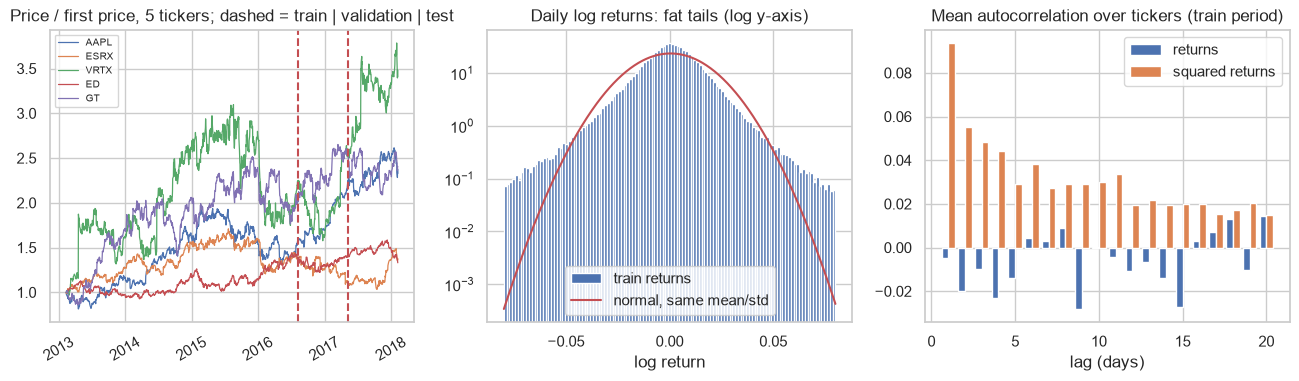

std of daily return 0.0170 | excess kurtosis 54.2 | lag-1 ACF of returns -0.005, of squared returns 0.094


In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
for i in np.linspace(0, nS - 1, 5).astype(int): ax[0].plot(days, close_a[i, 1:] / close_a[i, 1], lw=0.9, label=top[i])
ax[0].axvline(days[c1], c="C3", ls="--"); ax[0].axvline(days[c2], c="C3", ls="--"); ax[0].set(title="Price / first price, 5 tickers; dashed = train | validation | test"); ax[0].legend(fontsize=7); ax[0].tick_params(axis="x", rotation=30)
r = ret_raw[:, :c1].ravel(); xs = np.linspace(-0.08, 0.08, 400)
ax[1].hist(r, bins=np.linspace(-0.08, 0.08, 120), density=True, label="train returns"); ax[1].plot(xs, np.exp(-0.5 * ((xs - r.mean()) / r.std()) ** 2) / (r.std() * np.sqrt(2 * np.pi)), c="C3", label="normal, same mean/std")
ax[1].set_yscale("log"); ax[1].set(title="Daily log returns: fat tails (log y-axis)", xlabel="log return"); ax[1].legend()
def acf(a, k): return np.mean([np.corrcoef(x[:-k], x[k:])[0, 1] for x in a])
ks = range(1, 21); a_r = [acf(ret_raw[:, :c1], k) for k in ks]; a_s = [acf(ret_raw[:, :c1] ** 2, k) for k in ks]
ax[2].bar(np.array(ks) - 0.2, a_r, 0.4, label="returns"); ax[2].bar(np.array(ks) + 0.2, a_s, 0.4, label="squared returns"); ax[2].legend()
ax[2].set(xlabel="lag (days)", title="Mean autocorrelation over tickers (train period)")
fig.savefig(IMG / f"{CODE}_eda_returns.png"); plt.show()
print(f"std of daily return {r.std():.4f} | excess kurtosis {((r - r.mean())**4).mean() / r.var()**2 - 3:.1f} | lag-1 ACF of returns {a_r[0]:.3f}, of squared returns {a_s[0]:.3f}")

## 4. RNN from scratch (NumPy)  —  run `ST-SC-RNN`

**Recurrence.** $h_t=\tanh(x_tW_{xh}+h_{t-1}W_{hh}+b)$, $h_0=0$, and the prediction uses only the last state: $\hat y=h_TW_{hy}+b_y$. The same $W_{xh},W_{hh},b$ are reused at every time step (weight sharing), so the parameter count does not depend on $T$.

**Back-propagation through time.** With $z_t=x_tW_{xh}+h_{t-1}W_{hh}+b$ and loss $L=\frac1N\sum(\hat y-y)^2$:

$$\frac{\partial L}{\partial h_T}=\frac{2}{N}(\hat y-y)W_{hy}^\top,\qquad \frac{\partial L}{\partial z_t}=\frac{\partial L}{\partial h_t}\odot(1-h_t^2),\qquad \frac{\partial L}{\partial h_{t-1}}=\frac{\partial L}{\partial z_t}W_{hh}^\top$$

and the shared weights collect a contribution from every step: $\partial L/\partial W_{hh}=\sum_t h_{t-1}^\top\,\partial L/\partial z_t$ (likewise $W_{xh}$ with $x_t$, and $b$). The code loops over time only (vectorised over the batch). Gradients are clipped to a global norm of 1 and fed to a hand-written Adam.

**Shapes for this dataset.** Input $(N,30,4)$ → $x_t\in\mathbb R^{4}$, $h_t\in\mathbb R^{32}$ → $\hat y\in\mathbb R$. Parameters: $W_{xh}$ $4\times32=128$, $W_{hh}$ 1024, $b$ 32, head 33 → **1,217**.

In [5]:
class ScratchRNN:
    """Single-layer vanilla RNN, many-to-one: h_t = tanh(x_t Wxh + h_{t-1} Whh + b), yhat = h_T Why + by. NumPy only."""
    def __init__(self, F, H, seed=SEED, dtype=np.float32):
        rng = np.random.default_rng(seed)
        lim = np.sqrt(6 / (F + H))                                   # Glorot uniform (as Keras kernel)
        q, r = np.linalg.qr(rng.standard_normal((H, H)))             # orthogonal recurrent matrix (as Keras)
        lh = np.sqrt(6 / (H + 1))
        self.p = {"Wxh": rng.uniform(-lim, lim, (F, H)), "Whh": q * np.sign(np.diag(r)), "bh": np.zeros(H),
                  "Why": rng.uniform(-lh, lh, (H, 1)), "by": np.zeros(1)}
        self.p = {k: v.astype(dtype) for k, v in self.p.items()}

    def n_params(self): return int(sum(v.size for v in self.p.values()))

    def forward(self, X):
        p = self.p; N, Tn, _ = X.shape
        xw = X @ p["Wxh"]                                            # all x_t Wxh at once: (N, T, H)
        h = np.zeros((N, p["Whh"].shape[0]), X.dtype); hs = [h]
        for t in range(Tn):                                          # the only loop is over time
            h = np.tanh(xw[:, t] + h @ p["Whh"] + p["bh"]); hs.append(h)
        return (h @ p["Why"] + p["by"])[:, 0], hs

    def loss_grads(self, X, y):
        """MSE loss and its gradients by back-propagation through time. Also returns ||dL/dh_t||, t = 1..T."""
        p = self.p; yhat, hs = self.forward(X); N, Tn, _ = X.shape
        err = yhat - y; loss = float(np.mean(err ** 2))
        dy = (2.0 / N) * err[:, None]                                # dL/dyhat
        g = {k: np.zeros_like(v) for k, v in p.items()}
        g["Why"] = hs[-1].T @ dy; g["by"] = dy.sum(0)
        dh = dy @ p["Why"].T                                         # dL/dh_T
        norms = np.zeros(Tn)
        for t in range(Tn, 0, -1):
            norms[t - 1] = np.linalg.norm(dh)
            dz = dh * (1.0 - hs[t] ** 2)                             # through tanh: dL/dz_t
            g["Wxh"] += X[:, t - 1].T @ dz
            g["Whh"] += hs[t - 1].T @ dz
            g["bh"] += dz.sum(0)
            dh = dz @ p["Whh"].T                                     # dL/dh_{t-1}
        return loss, g, norms

    def predict(self, X, bs=4096):
        return np.concatenate([self.forward(X[i:i + bs])[0] for i in range(0, len(X), bs)])


class Adam:
    def __init__(self, params, lr=LR, b1=0.9, b2=0.999, eps=EPS):
        self.lr, self.b1, self.b2, self.eps, self.t = lr, b1, b2, eps, 0
        self.m = {k: np.zeros_like(v) for k, v in params.items()}; self.v = {k: np.zeros_like(v) for k, v in params.items()}
    def step(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] ** 2
            mh = self.m[k] / (1 - self.b1 ** self.t); vh = self.v[k] / (1 - self.b2 ** self.t)
            params[k] -= self.lr * mh / (np.sqrt(vh) + self.eps)


def clip_global_norm(grads, max_norm=CLIP):
    total = np.sqrt(sum(float((g.astype(np.float64) ** 2).sum()) for g in grads.values()))
    scale = min(1.0, max_norm / (total + 1e-6))
    for k in grads: grads[k] *= scale
    return total


def fit_scratch(model, Xtr, ytr, Xva, yva):
    opt = Adam(model.p); rng = np.random.default_rng(SEED)
    hist = {"loss": [], "val_loss": []}; times = []; best, wait, best_p = np.inf, 0, None
    t_all = time.perf_counter()
    for ep in range(MAX_EPOCHS):
        t0 = time.perf_counter(); perm = rng.permutation(len(Xtr)); tot = 0.0
        for i in range(0, len(perm), BATCH):
            idx = perm[i:i + BATCH]
            loss, g, _ = model.loss_grads(Xtr[idx], ytr[idx])
            clip_global_norm(g); opt.step(model.p, g); tot += loss * len(idx)
        val = float(np.mean((model.predict(Xva) - yva) ** 2))
        hist["loss"].append(tot / len(perm)); hist["val_loss"].append(val); times.append(time.perf_counter() - t0)
        if val < best - 1e-12: best, wait, best_p = val, 0, {k: v.copy() for k, v in model.p.items()}
        else: wait += 1
        if wait >= PATIENCE: break
    model.p = best_p                                                 # restore best weights
    return hist, times, time.perf_counter() - t_all

### Gradient check

Before trusting hand-written back-propagation, compare it with a central finite difference $\frac{L(\theta+\epsilon)-L(\theta-\epsilon)}{2\epsilon}$ ($\epsilon=10^{-6}$, float64) for **every** parameter on 8 real windows. The error is measured per parameter as $\max|a-n|\,/\,\max|a|$ (analytic $a$, numerical $n$), because entries whose gradient is almost zero would otherwise be dominated by finite-difference round-off. Below $10^{-5}$ means the BPTT code is right.

In [6]:
def gradient_check(F, n=8, eps=1e-6, seed=0):
    """Compare analytic BPTT gradients with central finite differences, in float64, on n real windows."""
    m = ScratchRNN(F, H, seed=seed, dtype=np.float64)
    for k in ("bh", "by"): m.p[k] = np.random.default_rng(1).normal(0, 0.1, m.p[k].shape)      # non-zero biases test those gradients too
    X, y = Xtr[:n].astype(np.float64), ytr[:n].astype(np.float64)
    _, g, _ = m.loss_grads(X, y); rows = []
    for k, v in m.p.items():
        num = np.zeros_like(v)
        for ix in np.ndindex(*v.shape):
            old = v[ix]; v[ix] = old + eps; lp = m.loss_grads(X, y)[0]; v[ix] = old - eps; lm = m.loss_grads(X, y)[0]; v[ix] = old
            num[ix] = (lp - lm) / (2 * eps)
        rel = np.abs(g[k] - num).max() / max(np.abs(g[k]).max(), 1e-12)      # error relative to the parameter's largest gradient entry
        rows.append((k, v.shape, float(rel)))
    return pd.DataFrame(rows, columns=["parameter", "shape", "max error / max |gradient|"])

gc = gradient_check(Xtr.shape[2]); display(gc)
assert gc['max error / max |gradient|'].max() < 1e-5, 'BPTT gradients disagree with finite differences'

,parameter,shape,max error / max |gradient|
0,Wxh,"(4, 32)",8.590652e-10
1,Whh,"(32, 32)",8.302950e-10
2,bh,"(32,)",1.579790e-09
3,Why,"(32, 1)",3.405910e-10
4,by,"(1,)",1.918839e-10


### Training

The scratch model starts from the weights `W0` (Glorot input matrix, orthogonal recurrent matrix, zero biases). The same `W0` is copied into the Keras and PyTorch models so that all three implementations begin from the identical function. Mini-batches are shuffled with a seeded generator; Keras and PyTorch shuffle with their own generators, so batch order is not bit-identical across frameworks.

scratch parameters: 1217  = F*H + H*H + H + H + 1 = 1217


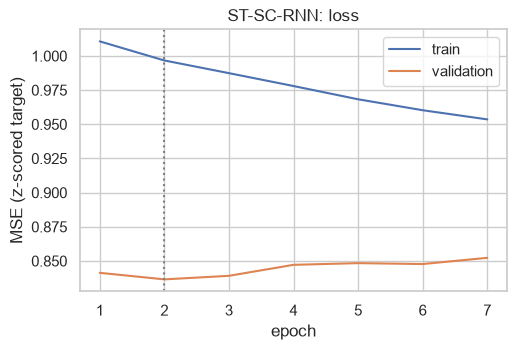

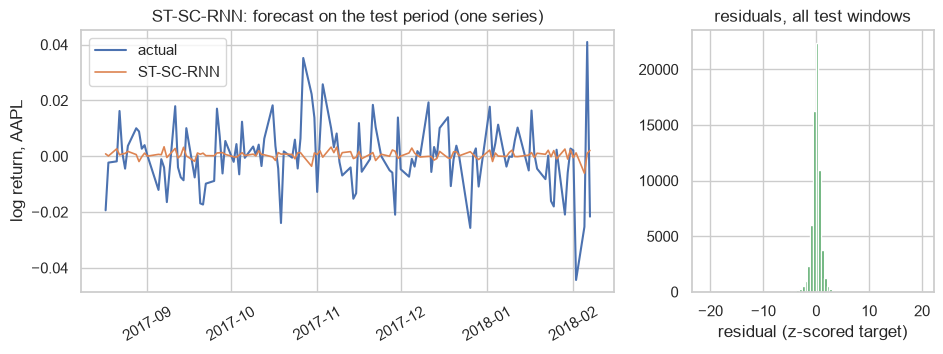

ST-SC-RNN: params 1,217 | epochs 7 (best 2) | 4.2s/epoch | total 29s | test rmse 0.0159, mae 0.0101, r2_oos -0.0171, dir_acc 0.5084, ic -0.0153


In [7]:
F_ = Xtr.shape[2]
W0 = {k: v.copy() for k, v in ScratchRNN(F_, H).p.items()}
sc = ScratchRNN(F_, H)
print('scratch parameters:', sc.n_params(), ' = F*H + H*H + H + H + 1 =', F_ * H + H * H + H + H + 1)
hist, times, total = fit_scratch(sc, Xtr, ytr, Xva, yva)
finalize(f'{CODE}-SC-RNN', 'Scratch', 'RNN', hist, sc.n_params(), times, total, sc.predict);

### Where does the gradient go?

$\partial L/\partial h_t$ is multiplied by $W_{hh}^\top\,\mathrm{diag}(1-h^2)$ for every step back in time, so the signal from the target return reaches a day 30 steps earlier only after 29 such products. The plot compares the initial weights with the trained ones: here training raised the gradient reaching the first day from 0.3 % to 2.3 % of the last-step gradient, so the network uses somewhat more of the window than at initialisation, but the signal from 30 days back is still small.

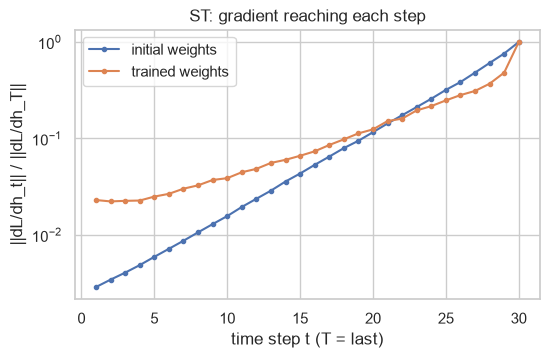

gradient at the first step is 0.023 of the gradient at the last step (trained), 0.003 (initial)


In [8]:
idx = np.random.default_rng(0).choice(len(Xte), 512, replace=False)
trained = sc.p; norms_trained = sc.loss_grads(Xte[idx], yte[idx])[2]
sc.p = ScratchRNN(F_, H).p; norms_init = sc.loss_grads(Xte[idx], yte[idx])[2]; sc.p = trained
fig, ax = plt.subplots(figsize=(6, 3.5))
for n_, l_ in ((norms_init, "initial weights"), (norms_trained, "trained weights")): ax.semilogy(range(1, T + 1), n_ / n_[-1], marker="o", ms=3, label=l_)
ax.set(xlabel="time step t (T = last)", ylabel="||dL/dh_t|| / ||dL/dh_T||", title=f"{CODE}: gradient reaching each step"); ax.legend()
fig.savefig(IMG / f"{CODE}-SC-RNN_gradnorm.png"); plt.show()
print(f"gradient at the first step is {norms_trained[0] / norms_trained[-1]:.3f} of the gradient at the last step (trained), {norms_init[0] / norms_init[-1]:.3f} (initial)")

## 5. RNN in Keras  —  runs `ST-TF-RNN`, `ST-TF-LSTM`, `ST-TF-GRU`

`SimpleRNN(32)` replaces the whole time loop of §4 and returns $h_{30}$; `Dense(1)` maps it to the predicted z-scored return. `fit` handles shuffling, Adam with `global_clipnorm=1.0` and early stopping with the best weights restored. The scratch weights `W0` are copied in with `set_weights([kernel (4,32), recurrent_kernel (32,32), bias (32)])`; the summary below should show 1,217 parameters.

In [9]:
def build_keras(kind, F, Tn, copy_init=None):
    cell = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[kind]
    m = keras.Sequential([layers.Input((Tn, F)), cell(H), layers.Dense(1)])
    m.compile(optimizer=keras.optimizers.Adam(LR, epsilon=EPS, global_clipnorm=CLIP), loss="mse")
    if copy_init is not None:                                        # SimpleRNN weights: [kernel (F,H), recurrent (H,H), bias (H)]
        m.layers[0].set_weights([copy_init["Wxh"], copy_init["Whh"], copy_init["bh"]])
        m.layers[1].set_weights([copy_init["Why"], copy_init["by"]])
    return m

class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.times = []
    def on_epoch_begin(self, epoch, logs=None): self.t0 = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.perf_counter() - self.t0)

def run_keras(kind, copy_init=None):
    run_id = f"{CODE}-TF-{kind}"; keras.utils.set_random_seed(SEED)
    m = build_keras(kind, Xtr.shape[2], Xtr.shape[1], copy_init)
    timer = EpochTimer(); es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    t0 = time.perf_counter()
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), batch_size=BATCH, epochs=MAX_EPOCHS, shuffle=True, callbacks=[es, timer], verbose=0)
    total = time.perf_counter() - t0
    pred = lambda X: m.predict(X, batch_size=4096, verbose=0)[:, 0]
    return finalize(run_id, "Keras", kind, h.history, m.count_params(), timer.times, total, pred)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,217 (4.75 KB)

 Trainable params: 1,217 (4.75 KB)

 Non-trainable params: 0 (0.00 B)

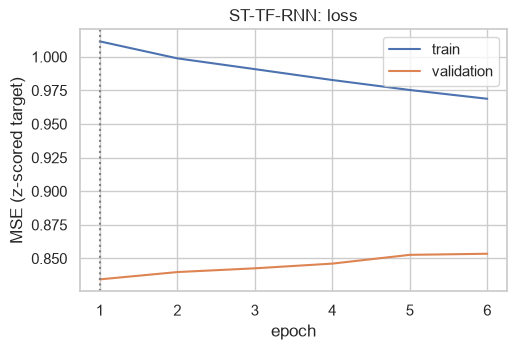

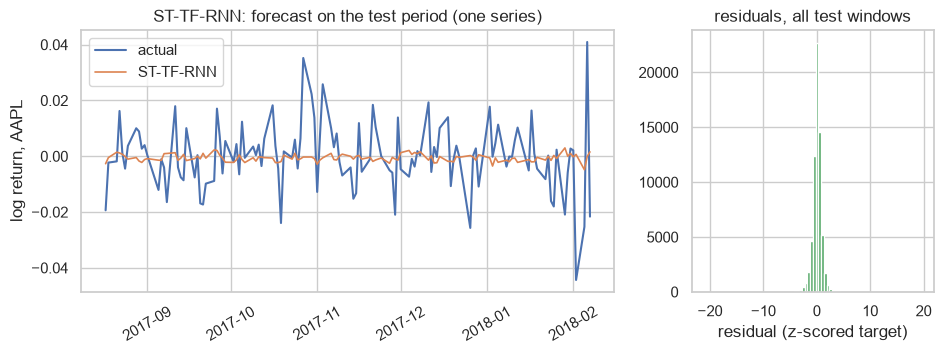

ST-TF-RNN: params 1,217 | epochs 6 (best 1) | 6.5s/epoch | total 43s | test rmse 0.0159, mae 0.0102, r2_oos -0.0171, dir_acc 0.4833, ic -0.0208


In [10]:
build_keras('RNN', Xtr.shape[2], T, W0).summary()
run_keras('RNN', copy_init=W0);

**Extras: LSTM and GRU.** Same data and settings, framework-default initialisation (Glorot input, orthogonal recurrent, zero bias; LSTM forget-gate bias 1 in Keras). They add gates (see `00_rnn_concepts.ipynb`), so they have 4× (LSTM) and 3× (GRU) the recurrent parameters.

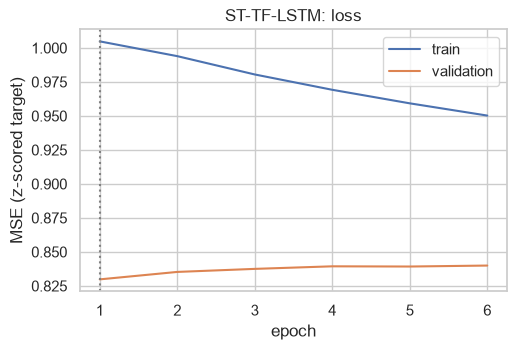

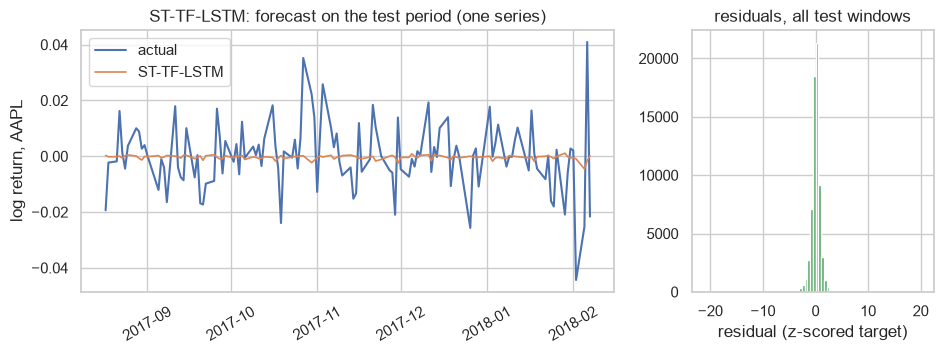

ST-TF-LSTM: params 4,769 | epochs 6 (best 1) | 14.9s/epoch | total 92s | test rmse 0.0158, mae 0.0101, r2_oos -0.0141, dir_acc 0.4835, ic -0.0206


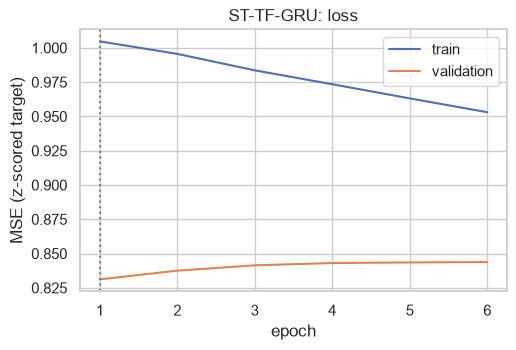

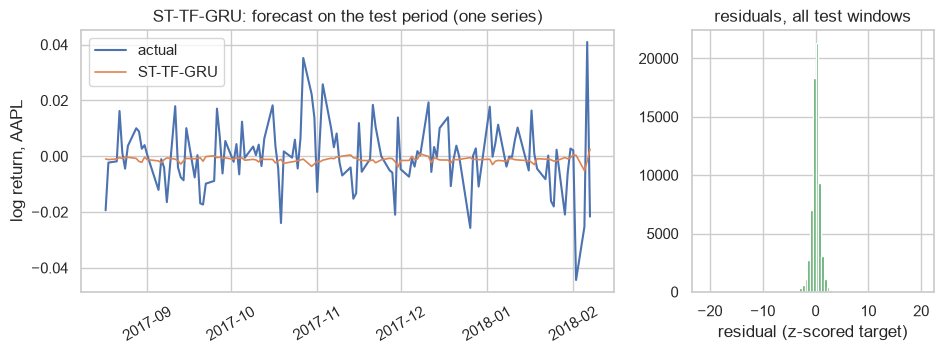

ST-TF-GRU: params 3,681 | epochs 6 (best 1) | 17.0s/epoch | total 104s | test rmse 0.0158, mae 0.0101, r2_oos -0.0150, dir_acc 0.4829, ic -0.0231


In [11]:
run_keras('LSTM'); run_keras('GRU');

## 6. RNN in PyTorch  —  runs `ST-PT-RNN`, `ST-PT-LSTM`, `ST-PT-GRU`

`nn.RNN(4, 32, batch_first=True)` gives the recurrence on `(N, 30, 4)` tensors and the loop `zero_grad → forward → backward → clip_grad_norm_ → step` is explicit. PyTorch's weight matrices are stored transposed (`weight_ih` is $32\times4$) and it carries two biases; the second is zeroed and frozen so that the core run also has 1,217 parameters.

In [12]:
class TorchSeq(nn.Module):
    def __init__(self, kind, F, hidden=H):
        super().__init__()
        self.rnn = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[kind](F, hidden, batch_first=True)   # nn.RNN default nonlinearity = tanh
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1]).squeeze(-1)                     # last time step only (many-to-one)

def build_torch(kind, F, copy_init=None):
    torch.manual_seed(SEED); m = TorchSeq(kind, F)
    if copy_init is not None:                                        # nn.RNN stores W_ih (H,F), W_hh (H,H): transpose of ours
        with torch.no_grad():
            m.rnn.weight_ih_l0.copy_(torch.from_numpy(copy_init["Wxh"].T)); m.rnn.weight_hh_l0.copy_(torch.from_numpy(copy_init["Whh"].T))
            m.rnn.bias_ih_l0.copy_(torch.from_numpy(copy_init["bh"])); m.rnn.bias_hh_l0.zero_()
            m.head.weight.copy_(torch.from_numpy(copy_init["Why"].T)); m.head.bias.copy_(torch.from_numpy(copy_init["by"]))
        m.rnn.bias_hh_l0.requires_grad_(False)                       # second bias frozen at 0 -> same parameter count as Keras / scratch
    return m.to(dev)

def n_trainable(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

def predict_torch(m, X, bs=4096):
    m.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), bs): out.append(m(torch.from_numpy(X[i:i + bs]).to(dev)).cpu().numpy())
    return np.concatenate(out)

def fit_torch(m):
    params = [p for p in m.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=LR, eps=EPS)
    Xt, yt = torch.from_numpy(Xtr).to(dev), torch.from_numpy(ytr).to(dev)
    Xv, yv = torch.from_numpy(Xva).to(dev), torch.from_numpy(yva).to(dev)
    gen = torch.Generator().manual_seed(SEED)
    hist = {"loss": [], "val_loss": []}; times = []; best, wait, best_state = np.inf, 0, None
    t_all = time.perf_counter()
    for ep in range(MAX_EPOCHS):
        t0 = time.perf_counter(); m.train(); perm = torch.randperm(len(Xt), generator=gen).to(dev); tot = torch.zeros((), device=dev)
        for i in range(0, len(perm), BATCH):
            idx = perm[i:i + BATCH]
            opt.zero_grad(set_to_none=True)
            loss = Fn.mse_loss(m(Xt[idx]), yt[idx]); loss.backward()
            torch.nn.utils.clip_grad_norm_(params, CLIP); opt.step()
            tot += loss.detach() * len(idx)
        m.eval()
        with torch.no_grad():
            val = sum(((m(Xv[i:i + 4096]) - yv[i:i + 4096]) ** 2).sum().item() for i in range(0, len(Xv), 4096)) / len(Xv)
        hist["loss"].append(tot.item() / len(perm)); hist["val_loss"].append(val); times.append(time.perf_counter() - t0)
        if val < best - 1e-12: best, wait, best_state = val, 0, {k: v.detach().clone() for k, v in m.state_dict().items()}
        else: wait += 1
        if wait >= PATIENCE: break
    m.load_state_dict(best_state)                                    # restore best weights
    return hist, times, time.perf_counter() - t_all

def run_torch(kind, copy_init=None):
    run_id = f"{CODE}-PT-{kind}"
    m = build_torch(kind, Xtr.shape[2], copy_init)
    hist, times, total = fit_torch(m)
    return finalize(run_id, "PyTorch", kind, hist, n_trainable(m), times, total, lambda X: predict_torch(m, X))

### Same weights, same output

Before training the PyTorch core model, check the claim *different names, same function*: with identical weights, the scratch, Keras and PyTorch forward passes must agree to float32 precision, and the parameter counts must match exactly.

In [13]:
xs = Xva[:64]
y_sc = ScratchRNN(F_, H).forward(xs)[0]
y_k = build_keras("RNN", F_, T, W0).predict(xs, verbose=0)[:, 0]
pm = build_torch("RNN", F_, W0); y_p = predict_torch(pm, xs)
print(f"max |scratch - Keras|   = {np.abs(y_sc - y_k).max():.2e}\nmax |scratch - PyTorch| = {np.abs(y_sc - y_p).max():.2e}\nmax |Keras - PyTorch|   = {np.abs(y_k - y_p).max():.2e}")
assert max(np.abs(y_sc - y_k).max(), np.abs(y_sc - y_p).max()) < 1e-4
n_k = build_keras("RNN", F_, T, W0).count_params(); n_p = n_trainable(pm); n_s = ScratchRNN(F_, H).n_params()
print("parameters  scratch / Keras / PyTorch:", n_s, n_k, n_p); assert n_s == n_k == n_p
pc = pd.DataFrame({k: {"Keras": build_keras(k, F_, T).count_params(), "PyTorch (all params)": sum(p.numel() for p in build_torch(k, F_).parameters())} for k in ("RNN", "GRU", "LSTM")}).T
display(pc)

max |scratch - Keras|   = 4.77e-07
max |scratch - PyTorch| = 3.58e-07
max |Keras - PyTorch|   = 3.28e-07
parameters  scratch / Keras / PyTorch: 1217 1217 1217


,Keras,PyTorch (all params)
RNN,1217,1249
GRU,3681,3681
LSTM,4769,4897


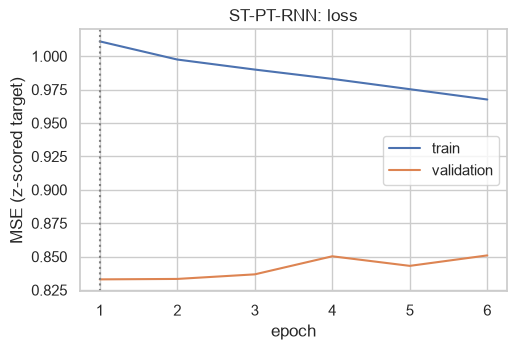

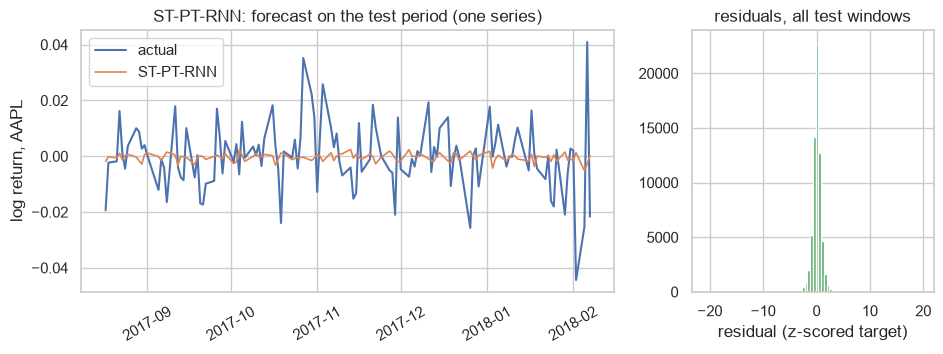

ST-PT-RNN: params 1,217 | epochs 6 (best 1) | 11.8s/epoch | total 70s | test rmse 0.0158, mae 0.0101, r2_oos -0.0165, dir_acc 0.4958, ic -0.0271


In [14]:
run_torch('RNN', copy_init=W0);

**Extras: LSTM and GRU** with PyTorch's default initialisation. `nn.LSTM` keeps two bias vectors per gate block (`b_ih`, `b_hh`), so it has 4·32 = 128 more parameters than Keras's LSTM; GRU matches because Keras uses `reset_after=True` (two biases) by default — see the table above.

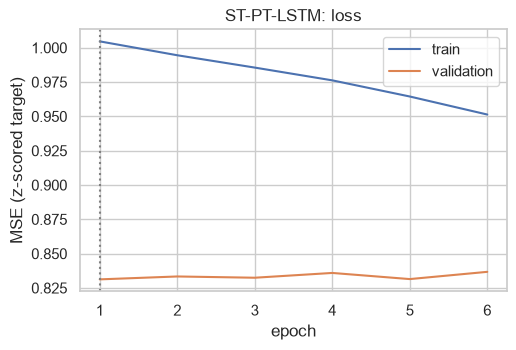

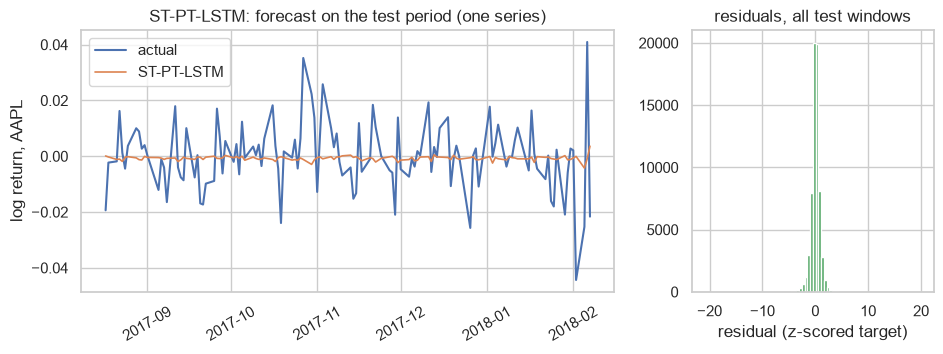

ST-PT-LSTM: params 4,897 | epochs 6 (best 1) | 20.3s/epoch | total 121s | test rmse 0.0158, mae 0.0101, r2_oos -0.0119, dir_acc 0.4927, ic -0.0223


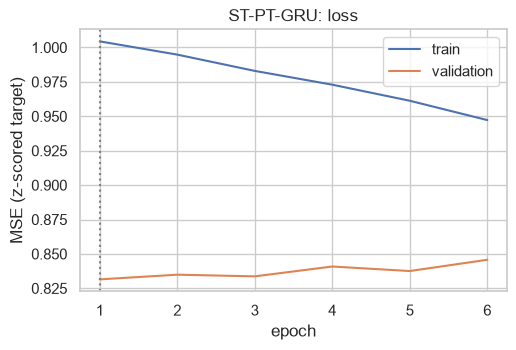

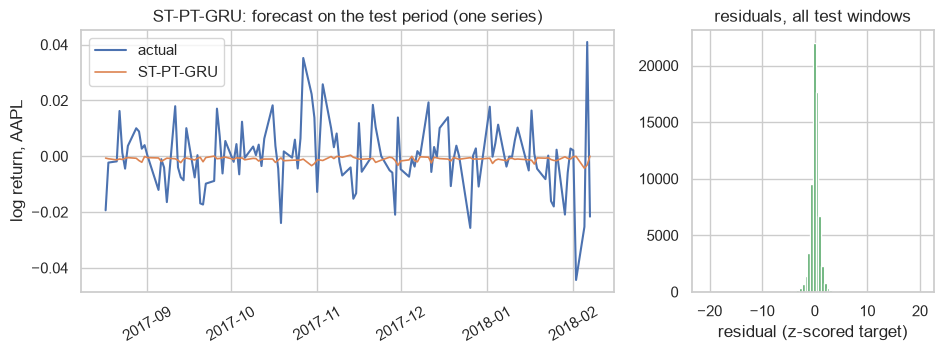

ST-PT-GRU: params 3,681 | epochs 6 (best 1) | 29.7s/epoch | total 179s | test rmse 0.0158, mae 0.0101, r2_oos -0.0129, dir_acc 0.4853, ic -0.0278


In [15]:
run_torch('LSTM'); run_torch('GRU');

## 7. Comparison

All numbers are on the **test** period (last 15 % of days, all 350 tickers). Reading guide: (a) does any RNN beat *zero return* and *previous-day return* in RMSE, and is R² above 0? (b) is directional accuracy above the always-up rate by more than noise? (c) do the three implementations agree? (d) cost per epoch.

In [16]:
rows = []
for name, p in BASELINES.items():
    rows.append(dict(run_id=f"baseline: {name}", impl="-", **metrics_fn(yte, p)))
for rid, r in RUNS.items():
    rows.append(dict(run_id=rid, impl=r["impl"], params=r["params"], epochs=r["epochs_run"], best_epoch=r["best_epoch"],
                     s_per_epoch=round(r["time_per_epoch_s"], 2), total_s=round(r["total_time_s"]), infer_ms_per_1k=round(r["infer_ms_per_1k"], 2), **r["test"]))
table = pd.DataFrame(rows).set_index("run_id")
table.to_csv(RES / f"{CODE}_comparison.csv")
display(table.style.format(precision=4, na_rep="").background_gradient(subset=[c for c in table.columns if c in ("rmse", "rmse_units")], cmap="Greens_r"))

,impl,rmse,mae,r2_oos,dir_acc,ic,params,epochs,best_epoch,s_per_epoch,total_s,infer_ms_per_1k
run_id,,,,,,,,,,,,
baseline: zero return,-,0.0157,0.0100,-0.0008,,,,,,,,
baseline: always up (+1e-6),-,0.0157,0.0100,-0.0008,,,,,,,,
baseline: previous-day return,-,0.0223,0.0146,-1.0164,0.4920,-0.0107,,,,,,
baseline: train mean,-,0.0157,0.0100,0.0000,0.5306,,,,,,,
ST-SC-RNN,Scratch,0.0159,0.0101,-0.0171,0.5084,-0.0153,1217.0000,7.0000,2.0000,4.1600,29.0000,6.1900
ST-TF-RNN,Keras,0.0159,0.0102,-0.0171,0.4833,-0.0208,1217.0000,6.0000,1.0000,6.4900,43.0000,7.3600
ST-TF-LSTM,Keras,0.0158,0.0101,-0.0141,0.4835,-0.0206,4769.0000,6.0000,1.0000,14.9200,92.0000,18.1900
ST-TF-GRU,Keras,0.0158,0.0101,-0.0150,0.4829,-0.0231,3681.0000,6.0000,1.0000,17.0200,104.0000,16.6000
ST-PT-RNN,PyTorch,0.0158,0.0101,-0.0165,0.4958,-0.0271,1217.0000,6.0000,1.0000,11.7500,70.0000,1.6300


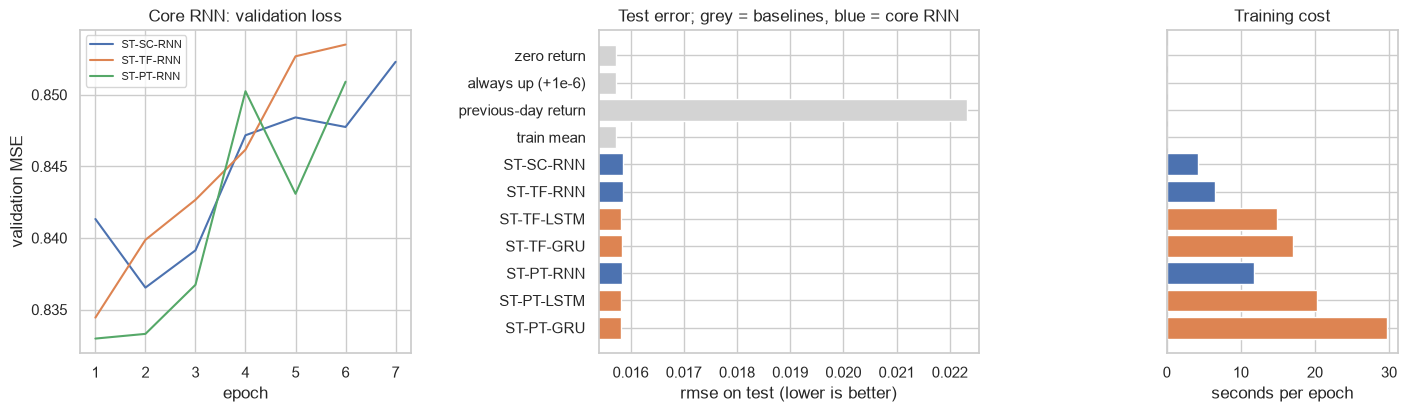

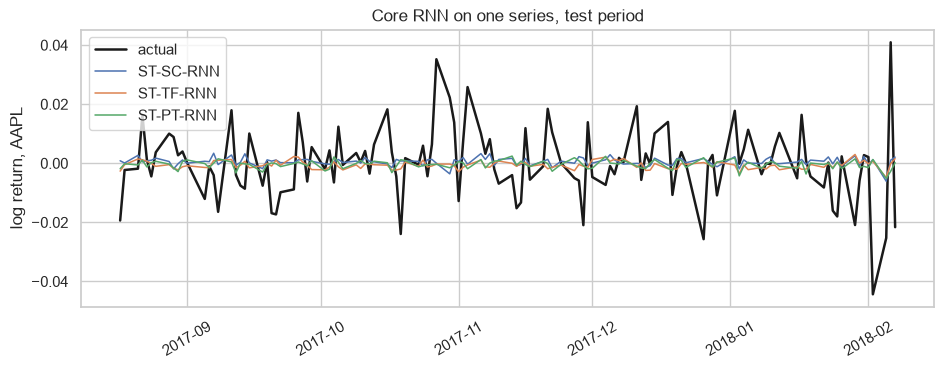

In [17]:
core = [f"{CODE}-SC-RNN", f"{CODE}-TF-RNN", f"{CODE}-PT-RNN"]
extra = [r for r in RUNS if r not in core]
fig = plt.figure(figsize=(17, 4.2)); gs = fig.add_gridspec(1, 3, wspace=0.6, width_ratios=[1, 1.15, 0.7])
a0 = fig.add_subplot(gs[0]); a1 = fig.add_subplot(gs[1]); a2 = fig.add_subplot(gs[2], sharey=a1)
for rid in core:
    h = RUNS[rid]["history"]; a0.plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], label=rid)
a0.set(xlabel="epoch", ylabel="validation MSE", title="Core RNN: validation loss"); a0.legend(fontsize=8)
rm = KEY_METRIC
labels = list(BASELINES) + list(RUNS); vals = [metrics_fn(yte, p)[rm] for p in BASELINES.values()] + [RUNS[r]["test"][rm] for r in RUNS]
colors = ["lightgrey"] * len(BASELINES) + ["C0" if r in core else "C1" for r in RUNS]
a1.barh(labels, vals, color=colors); a1.invert_yaxis(); a1.set(xlabel=rm + " on test (lower is better)", title="Test error; grey = baselines, blue = core RNN")
a1.set_xlim(min(vals) * 0.98, max(vals) * 1.01)
a2.barh(labels, [0] * len(BASELINES) + [RUNS[r]["time_per_epoch_s"] for r in RUNS], color=colors)
a2.set(xlabel="seconds per epoch", title="Training cost"); plt.setp(a2.get_yticklabels(), visible=False)
fig.savefig(IMG / f"{CODE}_compare.png"); plt.show()

fig, ax = plt.subplots(figsize=(11, 3.6))
xs, actual, _, ylabel = overlay_slice(RUNS[core[0]]["pred"])
ax.plot(xs, actual, c="k", lw=1.8, label="actual")
for rid in core: ax.plot(xs, overlay_slice(RUNS[rid]["pred"])[2], lw=1.1, label=rid)
ax.set(ylabel=ylabel, title="Core RNN on one series, test period"); ax.legend(); ax.tick_params(axis="x", rotation=30)
fig.savefig(IMG / f"{CODE}_overlay.png"); plt.show()

### One ticker, in price terms (demo only)

Turning the predicted return into a price, $\hat P_{t+1}=P_t e^{\hat r}$, makes every model look excellent because $P_t$ already carries almost all the information. It is shown only to illustrate that point; the return-space metrics above are the honest ones.

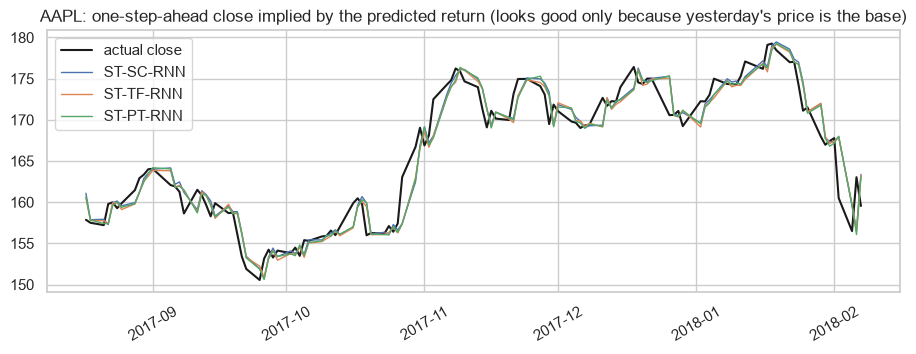

In [18]:
# visual demo only: one-step-ahead price implied by the predicted return, P_hat[t+1] = P[t] * exp(r_hat)
fig, ax = plt.subplots(figsize=(11, 3.4)); ix = np.where(te_ser == SHOW)[0][-120:]
p_prev = close_a[SHOW, te_day[ix]]                                           # close on the day before the target (close_a is offset by one day vs `days`)
ax.plot(days[te_day[ix]], close_a[SHOW, te_day[ix] + 1], c="k", label="actual close")
for rid in core: ax.plot(days[te_day[ix]], p_prev * np.exp(to_ret(RUNS[rid]["pred"][ix])), lw=1, label=rid)
ax.set(title=f"{top[SHOW]}: one-step-ahead close implied by the predicted return (looks good only because yesterday's price is the base)"); ax.legend(); ax.tick_params(axis="x", rotation=30)
fig.savefig(IMG / f"{CODE}_price_demo.png"); plt.show()

## 8. Conclusion

1. **No model beats the trivial forecast, as expected for returns.** Test RMSE is 0.0158–0.0159 for all seven RNNs versus 0.0157 for predicting zero or the train mean; out-of-sample R² is slightly negative (−0.012 to −0.017); the information coefficient is −0.015 to −0.028 (no usable correlation). Predicting yesterday's return is far worse (RMSE 0.0223, R² −1.02).
2. **Direction is not predictable either.** Directional accuracy is 48.3–50.8 %, below the 53.1 % obtained by always predicting "up" in the test period (a rising market). The best validation loss is reached at epoch 1–2 for every run, after which the models only fit noise.
3. **The implementations still agree.** Forward passes with the same weights differ by < 5e-7 and parameter counts match (1,217). The three core RNNs end at the same RMSE (0.0159, 0.0159, 0.0158) and R² (−0.017, −0.017, −0.017). That is the useful result of this notebook: the choice of scratch, Keras or PyTorch changes the code and the speed, not the learned function.
4. **Why it fails (EDA).** Returns have lag-1 autocorrelation −0.005 and excess kurtosis 54, while squared returns have autocorrelation 0.094: volatility is predictable, direction is not. A model trained with MSE on heavy-tailed returns is dominated by a few extreme days and gains nothing from the window.
5. **Cost.** Per epoch for the vanilla RNN: scratch 4.2 s, Keras 6.5 s, PyTorch 11.8 s; LSTM/GRU cost 2–3.5× more and do not help (R² −0.012 to −0.015). The honest conclusion for the report is a negative one.